# Lab 4 — Assignment


**Based on:** Lab-4-b (Bernoulli, Binomial, Poisson, Normal, Uniform)


---

### Instructions

1. Run the **Setup** cell first. Do not modify it.
2. There are **10 questions** — two on each distribution. Attempt **all** of them.
3. Every question has three parts:
   - **(a)** and **(b)** — work these out **by hand** and type your working in the *Written answer* cell.
   - **(c)** — write **Python code** in the blank code cell provided and produce the plot asked for.
4. Use `DISCRETE_COLOR` for discrete plots (bars) and `CONTINUOUS_COLOR` for continuous plots (curves).
5. Every plot must have an **x-label, y-label and a title**. Marks are deducted for unlabelled plots.
6. Round all probabilities to **4 decimal places**.
7. Save the notebook with all outputs visible before submitting.

### Marks distribution

| Section | Questions | Marks each | Total |
|---|---|---|---|
| A — Bernoulli | Q1, Q2 | 5 | 10 |
| B — Binomial | Q3, Q4 | 5 | 10 |
| C — Poisson | Q5, Q6 | 5 | 10 |
| D — Normal | Q7, Q8 | 5 | 10 |
| E — Uniform | Q9, Q10 | 5 | 10 |
| | | **Total** | **50** |

### Quick reference — which function do I need?

| Task | `scipy.stats` call |
|---|---|
| $P(X = k)$, discrete | `.pmf(k, ...)` |
| $f(x)$, continuous | `.pdf(x, ...)` |
| $P(X \le x)$ | `.cdf(x, ...)` |
| $P(X > x)$ | `.sf(x, ...)` |
| Value with given $P(X \le x)$ | `.ppf(prob, ...)` |
| Mean / variance | `.mean(...)`, `.var(...)` |
| Random samples | `.rvs(..., size=n, random_state=seed)` |

---

## Setup
Run this cell first — do not change it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp, sqrt

DISCRETE_COLOR = "#0E9F9A"     # teal   -> discrete distributions
CONTINUOUS_COLOR = "#E4572E"   # orange -> continuous distributions
HIGHLIGHT_COLOR = "#F4A261"    # use this to highlight a bar or a shaded area

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete — you are ready to start.")

Setup complete — you are ready to start.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
DISCRETE_COLOR = "skyblue"

---
# Part A — Bernoulli distribution
*Recall:* $P(X=x) = p^x(1-p)^{1-x}$ for $x \in \{0,1\}$, $\;E[X]=p$, $\;Var(X)=p(1-p)$.

## Q1. The library gate scanner 

> 📚 The RFID gate at the college library reads a student's ID card correctly on the **first tap 92%** of the time. One student taps her card once.
>
> Let $X = 1$ if the card is read on the first tap, and $X = 0$ if it is not.
>
> **(a)** State the value of $p$ and find $P(X=1)$ and $P(X=0)$.
> **(b)** Find the mean and the variance of $X$, showing the substitution into the formulas.
> **(c)** Write Python code that:
> - builds the PMF of $X$ using `stats.bernoulli.pmf`,
> - draws a **bar chart** of the distribution in `DISCRETE_COLOR` with the ticks labelled `"Not read (0)"` and `"Read (1)"`,
> - writes the probability value on top of each bar,
> - prints the mean and the variance obtained from `scipy`, and checks that they match your hand answers in (b).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


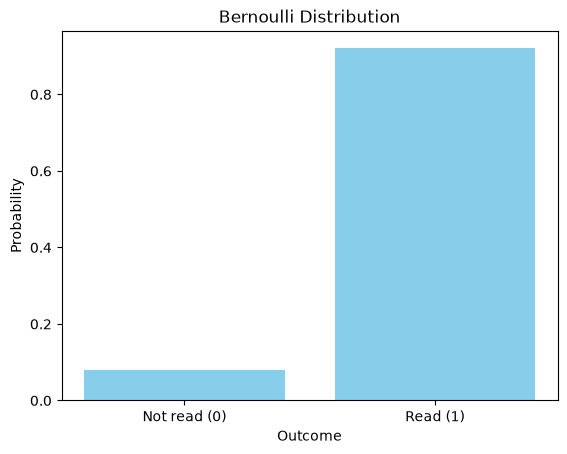

Mean = 0.92
Variance = 0.0736


In [5]:
x = [0, 1]
p = 0.92

pmf = stats.bernoulli.pmf(x, p)

plt.bar(x, pmf, color=DISCRETE_COLOR)
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.xticks(x, ["Not read (0)", "Read (1)"])
plt.title("Bernoulli Distribution")
plt.show()

print("Mean =", stats.bernoulli.mean(p))
print("Variance =", stats.bernoulli.var(p))

## Q2. Estimating $p$ from attendance data &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 👆 A biometric attendance device records whether a student's fingerprint is accepted on the **first attempt**. Over one semester the device logged **2,000 scans**, of which **1,740** were accepted on the first attempt. Treat one scan as a single Bernoulli trial with $X=1$ for *accepted*.
>
> **(a)** Estimate $p$ from the data and write down the full PMF $P(X=x)$ with the estimated value substituted in.
> **(b)** Find the mean and variance. Then answer: for what value of $p$ would the variance of a Bernoulli variable be the **largest possible**, and what is that largest value? Justify your answer using the formula $Var(X)=p(1-p)$.
> **(c)** Write Python code that:
> - simulates 2,000 Bernoulli trials with your estimated $p$ using `stats.bernoulli.rvs(..., random_state=42)`,
> - prints the **simulated proportion** of successes next to the theoretical $p$,
> - plots the **theoretical PMF and the simulated relative frequencies side by side** as grouped bars with a legend,
> - plots $Var(X)=p(1-p)$ against $p$ for $p$ from 0 to 1 in a **second figure**, and marks the maximum point with a marker and an annotation.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


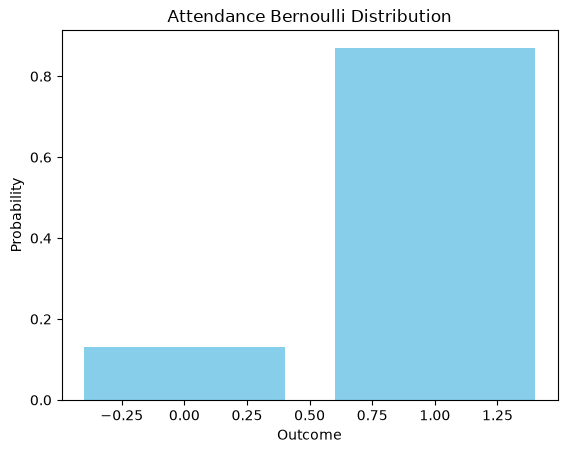

Mean = 0.87
Variance = 0.11309999999999998


In [6]:
p = 1740 / 2000
x = [0, 1]

pmf = stats.bernoulli.pmf(x, p)

plt.bar(x, pmf, color=DISCRETE_COLOR)
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("Attendance Bernoulli Distribution")
plt.show()

print("Mean =", stats.bernoulli.mean(p))
print("Variance =", stats.bernoulli.var(p))

---
# Part B — Binomial distribution
*Recall:* $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$, $\;E[X]=np$, $\;Var(X)=np(1-p)$.

## Q3. Guessing a multiple-choice quiz &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📝 An online quiz has **12 multiple-choice questions**, each with **4 options** and exactly one correct answer. A student who has not studied guesses every answer at random. Let $X$ = number of questions answered correctly.
>
> **(a)** State $n$ and $p$, check that the **BINS** conditions hold, and compute $P(X=5)$ **by hand**, showing the value of $\binom{12}{5}$.
> **(b)** Find the mean and the variance of $X$.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
>

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


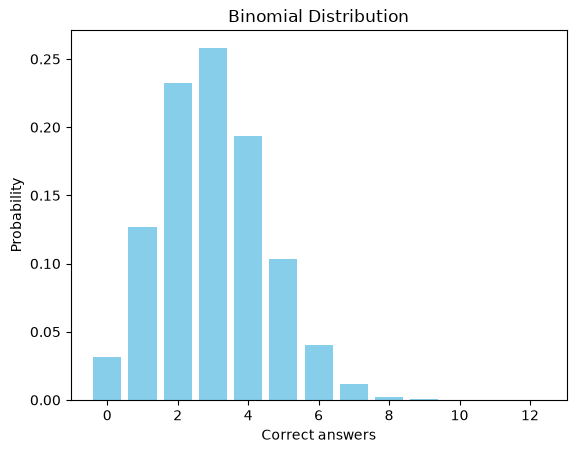

In [9]:
n = 12
p = 0.25
x = np.arange(0, 13)

pmf = stats.binom.pmf(x, n, p)

plt.bar(x, pmf, color=DISCRETE_COLOR)
plt.xlabel("Correct answers")
plt.ylabel("Probability")
plt.title("Binomial Distribution")
plt.show()

#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


---
# Part C — Poisson distribution
*Recall:* $P(X=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$, $\;E[X]=Var(X)=\lambda$.

## Q5. Help-desk emails &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📧 The IT help-desk of a college receives on average **3 emails per hour**. Let $X$ = number of emails received in one hour.
>
> **(a)** Compute $P(X = 0)$ and $P(X = 2)$ **by hand**, showing the substitution into the formula ($e^{-3} \approx 0.0498$).
> **(b)** State the mean and the variance, and explain in one line what is special about them for a Poisson distribution.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
> - prints $P(X=0)$, $P(X=2)$ and $P(X \le 5)$,
> - prints the smallest value of $k$ for which $P(X \le k) \ge 0.95$ (use `.ppf` or a loop).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


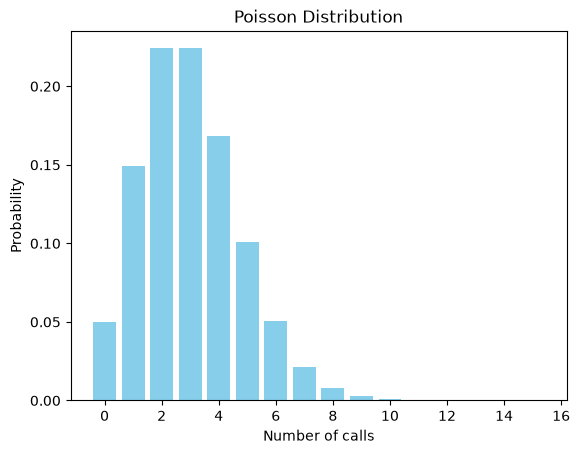

Mean = 3.0
Variance = 3.0
Smallest x = 6


In [10]:
lam = 3
x = np.arange(0, 16)

pmf = stats.poisson.pmf(x, lam)

plt.bar(x, pmf, color=DISCRETE_COLOR)
plt.xlabel("Number of calls")
plt.ylabel("Probability")
plt.title("Poisson Distribution")
plt.show()

print("Mean =", stats.poisson.mean(lam))
print("Variance =", stats.poisson.var(lam))

x95 = stats.poisson.ppf(0.95, lam)
print("Smallest x =", int(x95))

## Q6. Server errors over a night shift &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 🖥️ A web server logs errors at an average rate of **1.5 errors per hour**. The night shift runs from 10 pm to 6 am, i.e. **8 hours**.
>
> **(a)** Find the value of $\lambda$ for the **whole 8-hour shift**, and compute by hand the probability of a **clean shift** (zero errors in the 8 hours).
> **(b)** State the mean and variance for the 8-hour window. The on-call engineer is paged if **more than 18 errors** occur in the shift — write the expression for that probability and name the `scipy` function that gives it directly.
> **(c)** Write Python code that:
> - creates **two subplots side by side** — the PMF for the 1-hour window ($\lambda = 1.5$) and the PMF for the 8-hour window — each with its own sensible range of $k$, title and labels,


#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


In [11]:
lam = 1.5 * 8

print("P(X = 0) =", round(stats.poisson.pmf(0, lam), 4))
print("Mean =", lam)
print("Variance =", lam)
print("P(X > 18) =", round(stats.poisson.sf(18, lam), 4))

P(X = 0) = 0.0
Mean = 12.0
Variance = 12.0
P(X > 18) = 0.0374


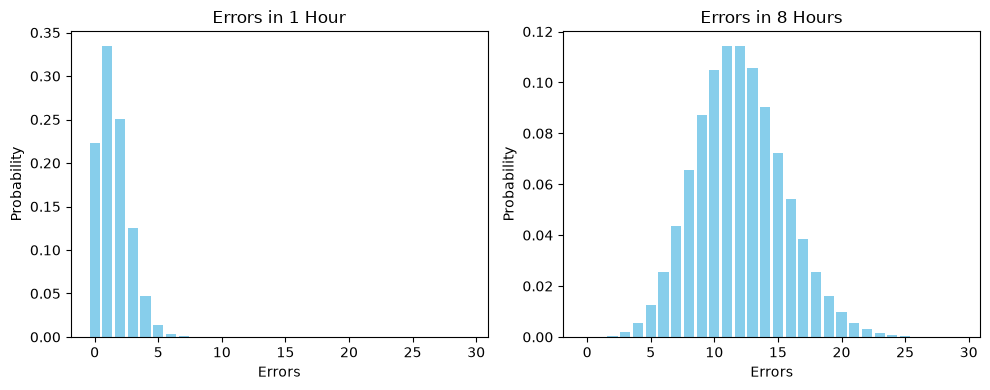

In [14]:
x = np.arange(0, 30)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(x, stats.poisson.pmf(x, 1.5), color=DISCRETE_COLOR)
plt.title("Errors in 1 Hour")
plt.xlabel("Errors")
plt.ylabel("Probability")

plt.subplot(1, 2, 2)
plt.bar(x, stats.poisson.pmf(x, 12), color=DISCRETE_COLOR)
plt.title("Errors in 8 Hours")
plt.xlabel("Errors")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()

---
# Part D — Normal distribution
*Recall:* $f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$, $\;Z=\dfrac{X-\mu}{\sigma}$, $\;E[X]=\mu$, $\;Var(X)=\sigma^2$.

## Q7. Battery life of a phone &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🔋 The battery life of a phone model is normally distributed with a mean of **18 hours** and a standard deviation of **1.5 hours**. Let $X$ = battery life of a randomly chosen phone.
>
> **(a)** Compute the **Z-score** for a battery life of 15 hours and say in words what that Z-score means.
> **(b)** Using the 68–95–99.7 rule, state the interval of battery lives that contains about **95%** of the phones. Show how you obtained it.
> **(c)** Write Python code that:
> - generates 400 equally spaced values of $x$ over $\mu \pm 4\sigma$ and computes the PDF,
> - plots the curve in `CONTINUOUS_COLOR` with a title and axis labels,
.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


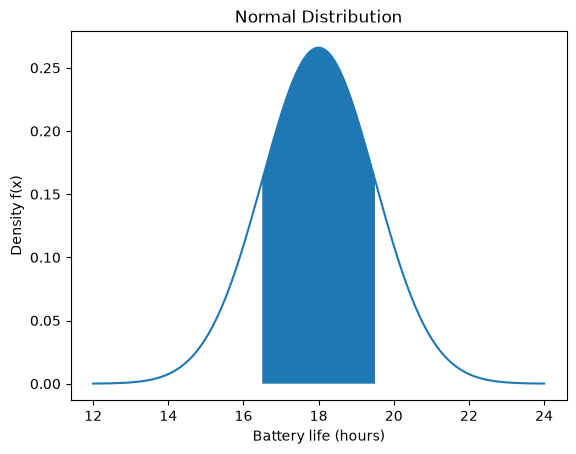

In [25]:
mu = 18
sigma = 1.5
c = 16.5
d = 19.5

x = np.linspace(12, 24, 400)
pdf = stats.norm.pdf(x, mu, sigma)

plt.plot(x, pdf)

x_interval = np.linspace(c, d, 100)
pdf_interval = stats.norm.pdf(x_interval, mu, sigma)

plt.fill_between(x_interval, pdf_interval)

plt.xlabel("Battery life (hours)")
plt.ylabel("Density f(x)")
plt.title("Normal Distribution")
plt.show()

## Q8. Calibrating a coffee machine &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> ☕ A vending machine fills cups with coffee. The fill volume is normally distributed with a mean of **200 ml**, but the standard deviation is **not known**. The service log shows that **2.5% of cups overflow**, which happens whenever the fill exceeds **210 ml**.
>
> **(a)** Using the standard normal value $z_{0.975} \approx 1.96$, find the standard deviation $\sigma$ of the fill volume. Show the working.
> **(b)** With that $\sigma$, find the volume below which only **1%** of cups fall (the 1st percentile), and state which `scipy` function gives it. A customer complains if the cup holds less than **190 ml** — write the expression for that probability.
> **(c)** Write Python code that:
> - computes $\sigma$ using `stats.norm.ppf` rather than the rounded 1.96,
> - plots the PDF over a sensible range in `CONTINUOUS_COLOR`,



#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


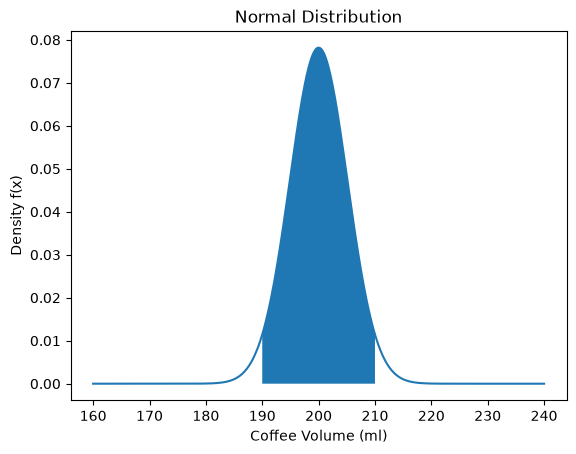

Standard deviation = 5.1021
1st percentile = 188.1307
P(X < 190) = 0.025


In [29]:
mu = 200
sigma = 10 / stats.norm.ppf(0.975)

c = 190
d = 210

x = np.linspace(160, 240, 400)
pdf = stats.norm.pdf(x, mu, sigma)

plt.plot(x, pdf)

x_interval = np.linspace(c, d, 100)
pdf_interval = stats.norm.pdf(x_interval, mu, sigma)

plt.fill_between(x_interval, pdf_interval)

plt.xlabel("Coffee Volume (ml)")
plt.ylabel("Density f(x)")
plt.title("Normal Distribution")
plt.show()

print("Standard deviation =", round(sigma, 4))
print("1st percentile =", round(stats.norm.ppf(0.01, mu, sigma), 4))
print("P(X < 190) =", round(stats.norm.cdf(190, mu, sigma), 4))

---
# Part E — Uniform distribution
*Recall:* $f(x)=\dfrac{1}{b-a}$ for $a \le x \le b$, $\;P(c \le X \le d)=\dfrac{d-c}{b-a}$, $\;E[X]=\dfrac{a+b}{2}$, $\;Var(X)=\dfrac{(b-a)^2}{12}$.

⚠️ **Note on `scipy`:** for a uniform distribution on $[a, b]$ you must use `loc=a` and `scale=b-a`, **not** `loc=a, scale=b`.

## Q9. Waiting for the campus shuttle &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🚌 The campus shuttle leaves the gate exactly every **15 minutes**. A student walks up to the stop at a completely random moment, so her waiting time $X$ is uniformly distributed between **0 and 15 minutes**.
>

> **(a)** Find the mean waiting time and the variance, showing the substitution.
> **(b)** Write Python code that:
> - plots the PDF as a flat line/rectangle over $[0, 15]$ in `CONTINUOUS_COLOR` (extend the x-axis a little beyond the range so the flat top is clear),


#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


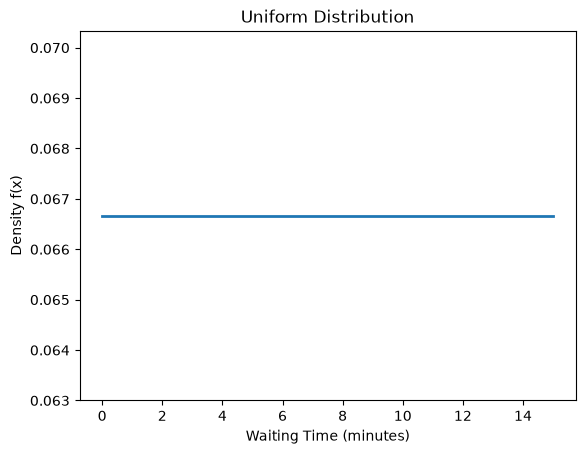

Mean = 7.5
Variance = 18.75


In [30]:
a = 0
b = 15
n = 1000

x = np.linspace(a, b, n)
pdf = stats.uniform.pdf(x, loc=a, scale=b-a)

plt.plot(x, pdf, lw=2)
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Density f(x)")
plt.title("Uniform Distribution")
plt.show()

print("Mean =", stats.uniform.mean(a, b))
print("Variance =", stats.uniform.var(a, b))